# 04 - Train Faster R-CNN ResNet50-FPN on DataPCB Final Clean 6-Class Dataset (Fixed)

This notebook is the unified two-stage detector benchmark notebook.

Purpose:

1. Train Faster R-CNN ResNet50-FPN on the merged final clean dataset.
2. Evaluate on merged test.
3. Evaluate source-wise on DeepPCB, DsPCBSD, and HRIPCB test subsets.
4. Export consistent CSV/PNG/JSON outputs for the later summary notebook.

Important design choices:

- YOLO labels are converted to Faster R-CNN labels by adding 1.
- Label 0 is reserved for background.
- Evaluation maps predictions/targets back to 0-5 class ids for reporting.
- Dataset is copied from `/kaggle/input` to `/kaggle/working` before training.
- Output schema is aligned with `nb02` and `nb03`:
  - `*_sourcewise_summary_metrics.csv`
  - `*_sourcewise_per_class_map.csv`
  - `*_sourcewise_per_class_pivot.csv`
  - `*_sourcewise_metrics.json`
  - source-wise figures

## Fix notes

This fixed version addresses the main issues found in the previous notebook:

1. `mAP50_95` became `-1.0` because `MeanAveragePrecision` was configured with `max_detection_thresholds=[1, 10, 300]`, while the standard COCO-style mAP expects the default `[1, 10, 100]`.
2. Faster R-CNN returned more than 100 detections per image, which caused TorchMetrics warnings. This version limits predictions to top-100 detections before metric computation.
3. Best checkpoint selection now uses a robust selection metric. If `mAP50_95` is unavailable, it falls back to `mAP50`.
4. Per-class AP values of `-1` are converted to `NaN` so the summary notebook can pivot cleanly.
5. Export logic for sample predictions is simplified.

6. Training log now uses text-only output instead of mixing dataframe display and print statements.

## 0. Install dependencies

In [1]:
%pip -q install torchmetrics pycocotools

Note: you may need to restart the kernel to use updated packages.


## 1. Imports and path config

In [2]:
from pathlib import Path
import random
import shutil
import json
import yaml
import time
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(i, torch.cuda.get_device_name(i))

ROOT = Path("/kaggle/working")

# Final clean merged dataset.
# The notebook supports multiple possible Kaggle dataset owners/paths.
POSSIBLE_SOURCE_ROOTS = [
    Path("/kaggle/input/datasets/chungkein/pcb-merged/DataPCB_Final_Clean_6cls"),
    Path("/kaggle/input/datasets/minhquan228/pcb-merged/DataPCB_Final_Clean_6cls"),
    Path("/kaggle/input/datasets/minhhieu/pcb-merged/DataPCB_Final_Clean_6cls"),
    Path("/kaggle/input/pcb-merged/DataPCB_Final_Clean_6cls"),
]

SOURCE_DATASET_ROOT = None
for p in POSSIBLE_SOURCE_ROOTS:
    print("Checking:", p, "| exists:", p.exists())
    if p.exists():
        SOURCE_DATASET_ROOT = p
        break

assert SOURCE_DATASET_ROOT is not None, "Could not find DataPCB_Final_Clean_6cls in expected Kaggle input paths."

DATA_DIR = ROOT / "DataPCB_Final_Clean_6cls"

PROJECT = "PCB_Baseline"
MODEL_NAME = "faster_rcnn_resnet50_fpn"
TRAIN_NAME = "faster_rcnn_resnet50_fpn_final_clean_6cls_e42"
PRED_NAME = "faster_rcnn_resnet50_fpn_final_clean_6cls_predictions"

REPORT_DIR = ROOT / "faster_rcnn_reports"
ARTIFACT_DIR = ROOT / "faster_rcnn_artifacts"
CHECKPOINT_DIR = ROOT / "faster_rcnn_checkpoints"
PRED_DIR = ROOT / "faster_rcnn_predictions" / PRED_NAME

REPORT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)

BEST_PT = CHECKPOINT_DIR / f"{TRAIN_NAME}_best.pth"
LAST_PT = CHECKPOINT_DIR / f"{TRAIN_NAME}_last.pth"
RESULTS_CSV = REPORT_DIR / f"{TRAIN_NAME}_results.csv"

CLASS_NAMES = [
    "missing_hole",
    "mouse_bite",
    "open_circuit",
    "short",
    "spur",
    "spurious_copper",
]

SOURCE_NAMES = ["DeepPCB", "DsPCBSD", "HRIPCB"]

NUM_DEFECT_CLASSES = len(CLASS_NAMES)
NUM_MODEL_CLASSES = NUM_DEFECT_CLASSES + 1  # background + 6 defects

IMG_SIZE = 640
EPOCHS = 42
BATCH_SIZE = 8
NUM_WORKERS = 4
LR = 0.005
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005
PATIENCE = 8
SEED = 42

CONF_THR = 0.25
MATCH_IOU_THR = 0.50
MAX_DETECTIONS_PER_IMAGE = 100  # COCO-style mAP uses maxDets=100.

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("SOURCE_DATASET_ROOT:", SOURCE_DATASET_ROOT)
print("DATA_DIR:", DATA_DIR)
print("DEVICE:", DEVICE)
print("NUM_MODEL_CLASSES:", NUM_MODEL_CLASSES)
print("MAX_DETECTIONS_PER_IMAGE:", MAX_DETECTIONS_PER_IMAGE)

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
CUDA available: True
CUDA device count: 2
0 Tesla T4
1 Tesla T4
Checking: /kaggle/input/datasets/chungkein/pcb-merged/DataPCB_Final_Clean_6cls | exists: False
Checking: /kaggle/input/datasets/minhquan228/pcb-merged/DataPCB_Final_Clean_6cls | exists: False
Checking: /kaggle/input/datasets/minhhieu/pcb-merged/DataPCB_Final_Clean_6cls | exists: True
SOURCE_DATASET_ROOT: /kaggle/input/datasets/minhhieu/pcb-merged/DataPCB_Final_Clean_6cls
DATA_DIR: /kaggle/working/DataPCB_Final_Clean_6cls
DEVICE: cuda:0
NUM_MODEL_CLASSES: 7
MAX_DETECTIONS_PER_IMAGE: 100


## 2. Copy dataset to `/kaggle/working`

In [3]:
FORCE_RECOPY = False

if FORCE_RECOPY and DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)

if DATA_DIR.exists():
    print("Dataset already exists in /kaggle/working:", DATA_DIR)
else:
    print("Copying dataset to /kaggle/working...")
    shutil.copytree(SOURCE_DATASET_ROOT, DATA_DIR)
    print("Copied:", DATA_DIR)

for split in ["train", "valid", "test"]:
    img_dir = DATA_DIR / split / "images"
    lbl_dir = DATA_DIR / split / "labels"
    print(split, "| images:", img_dir.exists(), "| labels:", lbl_dir.exists())
    assert img_dir.exists(), f"Missing image dir: {img_dir}"
    assert lbl_dir.exists(), f"Missing label dir: {lbl_dir}"

Copying dataset to /kaggle/working...
Copied: /kaggle/working/DataPCB_Final_Clean_6cls
train | images: True | labels: True
valid | images: True | labels: True
test | images: True | labels: True


## 3. Utility functions

In [4]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

def list_images(img_dir: Path):
    return sorted([p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS])

def detect_source_from_filename(name: str):
    if "__" not in name:
        return "UNKNOWN"
    return name.split("__", 1)[0]

def read_yolo_label(label_path: Path):
    objects = []
    errors = []

    if not label_path.exists():
        return objects, [{"file": str(label_path), "error": "missing label file"}]

    text = label_path.read_text().strip()
    if not text:
        return objects, []

    for line_idx, line in enumerate(text.splitlines(), start=1):
        parts = line.split()

        if len(parts) != 5:
            errors.append({
                "file": str(label_path),
                "line": line_idx,
                "content": line,
                "error": "YOLO label must contain exactly 5 values",
            })
            continue

        try:
            cls_id = int(float(parts[0]))
            x, y, w, h = map(float, parts[1:])
        except Exception as e:
            errors.append({
                "file": str(label_path),
                "line": line_idx,
                "content": line,
                "error": f"parse error: {e}",
            })
            continue

        if not (0 <= cls_id < len(CLASS_NAMES)):
            errors.append({
                "file": str(label_path),
                "line": line_idx,
                "content": line,
                "error": f"invalid class id: {cls_id}",
            })

        if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
            errors.append({
                "file": str(label_path),
                "line": line_idx,
                "content": line,
                "error": "bbox outside normalized YOLO range",
            })

        objects.append({"cls_id": cls_id, "x": x, "y": y, "w": w, "h": h})

    return objects, errors

def yolo_to_xyxy(obj, width, height):
    x = obj["x"] * width
    y = obj["y"] * height
    w = obj["w"] * width
    h = obj["h"] * height

    x1 = x - w / 2
    y1 = y - h / 2
    x2 = x + w / 2
    y2 = y + h / 2

    x1 = max(0, min(width - 1, x1))
    y1 = max(0, min(height - 1, y1))
    x2 = max(0, min(width - 1, x2))
    y2 = max(0, min(height - 1, y2))

    return [x1, y1, x2, y2]

def box_iou_np(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter = inter_w * inter_h

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)

    union = area_a + area_b - inter + 1e-9
    return inter / union

def collate_fn(batch):
    return tuple(zip(*batch))

def to_device(images, targets, device):
    images = [img.to(device) for img in images]
    targets = [
        {
            k: v.to(device) if torch.is_tensor(v) else v
            for k, v in t.items()
        }
        for t in targets
    ]
    return images, targets

def compute_f1(precision, recall):
    return 2 * (precision * recall) / (precision + recall + 1e-16)

## 4. Dataset class

In [5]:
class YOLODetectionDataset(Dataset):
    def __init__(self, data_dir: Path, split: str, img_size=640, source_filter=None):
        self.data_dir = Path(data_dir)
        self.split = split
        self.img_size = img_size
        self.source_filter = source_filter

        self.img_dir = self.data_dir / split / "images"
        self.lbl_dir = self.data_dir / split / "labels"

        images = list_images(self.img_dir)

        if source_filter is not None:
            images = [
                p for p in images
                if detect_source_from_filename(p.name) == source_filter
            ]

        self.images = images

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label_path = self.lbl_dir / f"{img_path.stem}.txt"

        img = cv2.imread(str(img_path))
        if img is None:
            raise FileNotFoundError(f"Could not read image: {img_path}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)

        H, W = img.shape[:2]

        objects, errors = read_yolo_label(label_path)
        if errors:
            raise ValueError(f"Label errors for {label_path}: {errors[:3]}")

        boxes = []
        labels = []

        for obj in objects:
            box = yolo_to_xyxy(obj, W, H)
            x1, y1, x2, y2 = box

            if x2 <= x1 or y2 <= y1:
                continue

            boxes.append(box)

            # Faster R-CNN label 0 is background. Defect classes are 1..6.
            labels.append(obj["cls_id"] + 1)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]) if len(boxes) else torch.zeros((0,), dtype=torch.float32)
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)

        image_id = torch.tensor([idx], dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd,
            "image_path": str(img_path),
        }

        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0

        return img, target

def make_loader(dataset, batch_size, shuffle=False, num_workers=4):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        collate_fn=collate_fn,
        pin_memory=True,
    )

## 5. Check dataset distribution

In [6]:
def summarize_dataset(data_dir: Path):
    summary_rows = []
    class_rows = []
    source_rows = []
    source_class_rows = []

    for split in ["train", "valid", "test"]:
        img_dir = data_dir / split / "images"
        lbl_dir = data_dir / split / "labels"

        images = list_images(img_dir)
        c = Counter()
        source_c = Counter()
        source_box_c = Counter()
        source_class_c = Counter()

        total_boxes = 0
        object_counts = []

        for img_path in images:
            source = detect_source_from_filename(img_path.name)
            label_path = lbl_dir / f"{img_path.stem}.txt"
            objects, errors = read_yolo_label(label_path)

            if errors:
                raise ValueError(f"Label errors in {label_path}: {errors[:3]}")

            source_c[source] += 1
            source_box_c[source] += len(objects)

            total_boxes += len(objects)
            object_counts.append(len(objects))

            for obj in objects:
                c[obj["cls_id"]] += 1
                source_class_c[(source, obj["cls_id"])] += 1

        summary_rows.append({
            "split": split,
            "num_images": len(images),
            "total_boxes": total_boxes,
            "mean_boxes_per_image": total_boxes / max(1, len(images)),
            "max_boxes_per_image": max(object_counts) if object_counts else 0,
        })

        for cls_id, cls_name in enumerate(CLASS_NAMES):
            class_rows.append({
                "split": split,
                "class_id": cls_id,
                "class_name": cls_name,
                "num_boxes": int(c.get(cls_id, 0)),
            })

        for source, n_images in sorted(source_c.items()):
            source_rows.append({
                "split": split,
                "source": source,
                "num_images": int(n_images),
                "num_boxes": int(source_box_c[source]),
            })

            for cls_id, cls_name in enumerate(CLASS_NAMES):
                source_class_rows.append({
                    "split": split,
                    "source": source,
                    "class_id": cls_id,
                    "class_name": cls_name,
                    "num_boxes": int(source_class_c[(source, cls_id)]),
                })

    return (
        pd.DataFrame(summary_rows),
        pd.DataFrame(class_rows),
        pd.DataFrame(source_rows),
        pd.DataFrame(source_class_rows),
    )

dataset_summary_df, class_distribution_df, source_summary_df, source_class_df = summarize_dataset(DATA_DIR)

display(dataset_summary_df)
display(class_distribution_df)
display(source_summary_df)
display(source_class_df)

dataset_summary_df.to_csv(REPORT_DIR / "dataset_summary.csv", index=False)
class_distribution_df.to_csv(REPORT_DIR / "class_distribution.csv", index=False)
source_summary_df.to_csv(REPORT_DIR / "source_summary.csv", index=False)
source_class_df.to_csv(REPORT_DIR / "source_class_distribution.csv", index=False)

,split,num_images,total_boxes,mean_boxes_per_image,max_boxes_per_image
0,train,6624,19176,2.894928,25
1,valid,937,2712,2.894344,20
2,test,1887,5352,2.836248,27


,split,class_id,class_name,num_boxes
0,train,0,missing_hole,3417
1,train,1,mouse_bite,3517
2,train,2,open_circuit,3007
3,train,3,short,2077
4,train,4,spur,4599
5,train,5,spurious_copper,2559
6,valid,0,missing_hole,478
7,valid,1,mouse_bite,460
8,valid,2,open_circuit,411
9,valid,3,short,307


,split,source,num_images,num_boxes
0,train,DeepPCB,1050,7166
1,train,DsPCBSD,5089,9936
2,train,HRIPCB,485,2074
3,valid,DeepPCB,150,1003
4,valid,DsPCBSD,718,1411
5,valid,HRIPCB,69,298
6,test,DeepPCB,300,1844
7,test,DsPCBSD,1448,2927
8,test,HRIPCB,139,581


,split,source,class_id,class_name,num_boxes
0,train,DeepPCB,0,missing_hole,1038
1,train,DeepPCB,1,mouse_bite,1401
2,train,DeepPCB,2,open_circuit,1409
3,train,DeepPCB,3,short,1106
4,train,DeepPCB,4,spur,1161
5,train,DeepPCB,5,spurious_copper,1051
6,train,DsPCBSD,0,missing_hole,2003
7,train,DsPCBSD,1,mouse_bite,1749
8,train,DsPCBSD,2,open_circuit,1253
9,train,DsPCBSD,3,short,654


## 6. Build datasets and loaders

In [7]:
train_dataset = YOLODetectionDataset(DATA_DIR, split="train", img_size=IMG_SIZE)
valid_dataset = YOLODetectionDataset(DATA_DIR, split="valid", img_size=IMG_SIZE)
test_dataset = YOLODetectionDataset(DATA_DIR, split="test", img_size=IMG_SIZE)

source_test_datasets = {
    "Merged": test_dataset,
}

for source in SOURCE_NAMES:
    ds = YOLODetectionDataset(DATA_DIR, split="test", img_size=IMG_SIZE, source_filter=source)
    source_test_datasets[source] = ds
    print(source, "test images:", len(ds))

train_loader = make_loader(train_dataset, BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
valid_loader = make_loader(valid_dataset, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

source_test_loaders = {
    source: make_loader(ds, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    for source, ds in source_test_datasets.items()
}

print("train:", len(train_dataset))
print("valid:", len(valid_dataset))
print("test merged:", len(test_dataset))

DeepPCB test images: 300
DsPCBSD test images: 1448
HRIPCB test images: 139
train: 6624
valid: 937
test merged: 1887


## 7. Build Faster R-CNN model

In [8]:
def build_faster_rcnn(num_classes):
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT

    model = fasterrcnn_resnet50_fpn(
        weights=weights,
        box_score_thresh=0.05,
        box_nms_thresh=0.5,
        box_detections_per_img=MAX_DETECTIONS_PER_IMAGE,
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

model = build_faster_rcnn(NUM_MODEL_CLASSES)
model.to(DEVICE)

params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=12,
    gamma=0.1,
)

scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

print(model.__class__.__name__)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 216MB/s]


FasterRCNN


## 8. Training and evaluation helpers

In [9]:
def train_one_epoch(model, loader, optimizer, scaler, device):
    model.train()

    total_loss = 0.0
    loss_sums = defaultdict(float)
    n_batches = 0

    start = time.time()

    for images, targets in loader:
        images, targets = to_device(images, targets, device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += float(losses.detach().cpu())
        for k, v in loss_dict.items():
            loss_sums[k] += float(v.detach().cpu())

        n_batches += 1

    elapsed = time.time() - start

    row = {
        "train_loss": total_loss / max(1, n_batches),
        "train_time_sec": elapsed,
    }

    for k, v in loss_sums.items():
        row[f"train_{k}"] = v / max(1, n_batches)

    return row


@torch.no_grad()
def evaluate_loss(model, loader, device):
    # Faster R-CNN returns losses only in train mode.
    # This is used for validation loss only.
    was_training = model.training
    model.train()

    total_loss = 0.0
    loss_sums = defaultdict(float)
    n_batches = 0

    for images, targets in loader:
        images, targets = to_device(images, targets, device)

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        total_loss += float(losses.detach().cpu())
        for k, v in loss_dict.items():
            loss_sums[k] += float(v.detach().cpu())

        n_batches += 1

    if not was_training:
        model.eval()

    row = {
        "val_loss": total_loss / max(1, n_batches),
    }

    for k, v in loss_sums.items():
        row[f"val_{k}"] = v / max(1, n_batches)

    return row


def clean_metric_value(value):
    """Convert torchmetrics unavailable values (-1) into NaN."""
    if torch.is_tensor(value):
        value = float(value.detach().cpu())
    else:
        value = float(value)

    if value < 0:
        return np.nan

    return value


def get_selection_metric(summary_row):
    """
    Primary selection metric: mAP50-95.
    Fallback: mAP50 if mAP50-95 is unavailable.
    """
    m = summary_row.get("mAP50_95", np.nan)

    if m is not None and np.isfinite(m) and m >= 0:
        return float(m)

    fallback = summary_row.get("mAP50", -1.0)
    if fallback is not None and np.isfinite(fallback):
        return float(fallback)

    return -1.0


def convert_preds_for_metrics(outputs, score_thr=0.001, max_dets=100):
    preds = []

    for out in outputs:
        boxes = out["boxes"].detach().cpu()
        scores = out["scores"].detach().cpu()
        labels = out["labels"].detach().cpu()

        keep = scores >= score_thr

        boxes = boxes[keep]
        scores = scores[keep]
        labels = labels[keep]

        # Convert Faster R-CNN labels 1..6 back to metric labels 0..5.
        labels = labels - 1

        valid = (labels >= 0) & (labels < NUM_DEFECT_CLASSES)

        boxes = boxes[valid]
        scores = scores[valid]
        labels = labels[valid].to(torch.int64)

        # TorchMetrics/COCO mAP convention uses maxDets=100.
        # Limit to top-100 predictions to avoid "more than 100 detections" warnings
        # and to keep mAP50-95 valid.
        if len(scores) > max_dets:
            order = torch.argsort(scores, descending=True)[:max_dets]
            boxes = boxes[order]
            scores = scores[order]
            labels = labels[order]

        preds.append({
            "boxes": boxes,
            "scores": scores,
            "labels": labels,
        })

    return preds


def convert_targets_for_metrics(targets):
    converted = []

    for t in targets:
        boxes = t["boxes"].detach().cpu()
        labels = t["labels"].detach().cpu() - 1

        valid = (labels >= 0) & (labels < NUM_DEFECT_CLASSES)

        converted.append({
            "boxes": boxes[valid],
            "labels": labels[valid].to(torch.int64),
        })

    return converted


def compute_precision_recall_at_iou(preds, targets, score_thr=0.25, iou_thr=0.50):
    tp = 0
    fp = 0
    fn = 0

    for pred, target in zip(preds, targets):
        p_boxes = pred["boxes"].numpy()
        p_scores = pred["scores"].numpy()
        p_labels = pred["labels"].numpy()

        t_boxes = target["boxes"].numpy()
        t_labels = target["labels"].numpy()

        keep = p_scores >= score_thr
        p_boxes = p_boxes[keep]
        p_scores = p_scores[keep]
        p_labels = p_labels[keep]

        order = np.argsort(-p_scores)
        p_boxes = p_boxes[order]
        p_labels = p_labels[order]

        matched_gt = set()

        for pb, pl in zip(p_boxes, p_labels):
            best_iou = 0.0
            best_j = -1

            for j, (tb, tl) in enumerate(zip(t_boxes, t_labels)):
                if j in matched_gt:
                    continue
                if int(pl) != int(tl):
                    continue

                iou = box_iou_np(pb, tb)

                if iou > best_iou:
                    best_iou = iou
                    best_j = j

            if best_iou >= iou_thr and best_j >= 0:
                tp += 1
                matched_gt.add(best_j)
            else:
                fp += 1

        fn += len(t_boxes) - len(matched_gt)

    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)
    f1 = compute_f1(precision, recall)

    return precision, recall, f1, tp, fp, fn


@torch.no_grad()
def evaluate_detection(model, loader, device, test_source):
    model.eval()

    metric = MeanAveragePrecision(
        box_format="xyxy",
        iou_type="bbox",
        class_metrics=True,
        # Keep default COCO-style maxDets=[1, 10, 100].
        # Do NOT set [1, 10, 300], because torchmetrics may report mAP as -1.
    )

    # Additional safety. Predictions are already top-100, so this should not trigger.
    if hasattr(metric, "warn_on_many_detections"):
        metric.warn_on_many_detections = False

    all_preds = []
    all_targets = []

    start = time.time()
    n_images = 0

    for images, targets in loader:
        images, targets = to_device(images, targets, device)

        outputs = model(images)

        preds_cpu = convert_preds_for_metrics(
            outputs,
            score_thr=0.001,
            max_dets=MAX_DETECTIONS_PER_IMAGE,
        )
        targets_cpu = convert_targets_for_metrics(targets)

        metric.update(preds_cpu, targets_cpu)

        all_preds.extend(preds_cpu)
        all_targets.extend(targets_cpu)

        n_images += len(images)

    elapsed = time.time() - start
    metric_result = metric.compute()

    precision, recall, f1, tp, fp, fn = compute_precision_recall_at_iou(
        all_preds,
        all_targets,
        score_thr=CONF_THR,
        iou_thr=MATCH_IOU_THR,
    )

    mAP50_95 = clean_metric_value(metric_result["map"])
    mAP50 = clean_metric_value(metric_result["map_50"])

    inference_ms = 1000 * elapsed / max(1, n_images)
    fps = 1000 / inference_ms if inference_ms > 0 else None

    summary_row = {
        "experiment": TRAIN_NAME,
        "model_name": MODEL_NAME,
        "test_source": test_source,
        "weights": str(BEST_PT if BEST_PT.exists() else LAST_PT),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "mAP50": mAP50,
        "mAP50_95": mAP50_95,
        "inference_ms_per_image": float(inference_ms),
        "FPS": float(fps) if fps is not None else None,
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "score_threshold_for_pr": CONF_THR,
        "iou_threshold_for_pr": MATCH_IOU_THR,
        "max_detections_per_image": MAX_DETECTIONS_PER_IMAGE,
    }

    per_class_rows = []

    map_per_class = metric_result.get("map_per_class", None)
    classes = metric_result.get("classes", None)

    if map_per_class is not None and classes is not None:
        map_per_class = map_per_class.detach().cpu().numpy().tolist()
        classes = classes.detach().cpu().numpy().tolist()

        for cls_id, ap in zip(classes, map_per_class):
            cls_id = int(cls_id)
            if 0 <= cls_id < len(CLASS_NAMES):
                ap_value = float(ap)
                if ap_value < 0:
                    ap_value = np.nan

                per_class_rows.append({
                    "experiment": TRAIN_NAME,
                    "model_name": MODEL_NAME,
                    "test_source": test_source,
                    "class_id": cls_id,
                    "class_name": CLASS_NAMES[cls_id],
                    "mAP50_95": ap_value,
                })

    # Fill missing classes with NaN so summary notebook can pivot cleanly.
    present = {r["class_id"] for r in per_class_rows}
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        if cls_id not in present:
            per_class_rows.append({
                "experiment": TRAIN_NAME,
                "model_name": MODEL_NAME,
                "test_source": test_source,
                "class_id": cls_id,
                "class_name": cls_name,
                "mAP50_95": np.nan,
            })

    return summary_row, per_class_rows

def format_float(value, digits=4):
    if value is None:
        return "None"
    try:
        if not np.isfinite(value):
            return "nan"
        return f"{float(value):.{digits}f}"
    except Exception:
        return str(value)


def print_epoch_log(epoch, total_epochs, row, best_metric, best_epoch, improved, epochs_without_improvement, patience):
    line_1 = (
        f"Epoch {epoch:02d}/{total_epochs} | "
        f"lr={row.get('lr', 0):.6f} | "
        f"train_loss={format_float(row.get('train_loss'))} | "
        f"val_loss={format_float(row.get('val_loss'))}"
    )

    line_2 = (
        f"val: P={format_float(row.get('val_precision'))} | "
        f"R={format_float(row.get('val_recall'))} | "
        f"F1={format_float(row.get('val_f1'))} | "
        f"mAP50={format_float(row.get('val_mAP50'))} | "
        f"mAP50-95={format_float(row.get('val_mAP50_95'))} | "
        f"select={format_float(row.get('val_selection_metric'))}"
    )

    line_3 = (
        f"time={format_float(row.get('train_time_sec'), 1)}s | "
        f"best={format_float(best_metric)} @ epoch {best_epoch} | "
        f"improved={improved} | "
        f"early_stop={epochs_without_improvement}/{patience}"
    )

    print(line_1)
    print(line_2)
    print(line_3)
    print("-" * 100)


## 9. Train

Text-only epoch logs are printed. Full epoch metrics are still saved to `RESULTS_CSV` for plotting and summary analysis.


In [10]:
best_val_selection_metric = -1.0
best_val_mAP50_95 = np.nan
best_epoch = -1
epochs_without_improvement = 0

history_rows = []

for epoch in range(1, EPOCHS + 1):
    train_row = train_one_epoch(model, train_loader, optimizer, scaler, DEVICE)
    val_loss_row = evaluate_loss(model, valid_loader, DEVICE)

    val_summary, _ = evaluate_detection(model, valid_loader, DEVICE, test_source="valid")

    lr_scheduler.step()

    val_selection_metric = get_selection_metric(val_summary)

    epoch_row = {
        "epoch": epoch,
        "lr": optimizer.param_groups[0]["lr"],
        **train_row,
        **val_loss_row,
        "val_precision": val_summary["precision"],
        "val_recall": val_summary["recall"],
        "val_f1": val_summary["f1"],
        "val_mAP50": val_summary["mAP50"],
        "val_mAP50_95": val_summary["mAP50_95"],
        "val_selection_metric": val_selection_metric,
    }

    history_rows.append(epoch_row)
    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(RESULTS_CSV, index=False)

    # Save last checkpoint every epoch.
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "class_names": CLASS_NAMES,
        "img_size": IMG_SIZE,
        "num_model_classes": NUM_MODEL_CLASSES,
        "train_name": TRAIN_NAME,
    }, LAST_PT)

    improved = False

    if val_selection_metric > best_val_selection_metric:
        improved = True
        best_val_selection_metric = val_selection_metric
        best_val_mAP50_95 = val_summary["mAP50_95"]
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "class_names": CLASS_NAMES,
            "img_size": IMG_SIZE,
            "num_model_classes": NUM_MODEL_CLASSES,
            "train_name": TRAIN_NAME,
            "best_val_selection_metric": best_val_selection_metric,
            "best_val_mAP50_95": best_val_mAP50_95,
        }, BEST_PT)

    else:
        epochs_without_improvement += 1

    print_epoch_log(
        epoch=epoch,
        total_epochs=EPOCHS,
        row=epoch_row,
        best_metric=best_val_selection_metric,
        best_epoch=best_epoch,
        improved=improved,
        epochs_without_improvement=epochs_without_improvement,
        patience=PATIENCE,
    )

    if improved:
        print(f"Saved new best checkpoint: {BEST_PT}")
        print("-" * 100)

    if epochs_without_improvement >= PATIENCE:
        print(
            f"Early stopping triggered at epoch {epoch}. "
            f"Best epoch={best_epoch}, "
            f"best_selection_metric={format_float(best_val_selection_metric)}, "
            f"best_mAP50-95={format_float(best_val_mAP50_95)}"
        )
        break

print("Training completed.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation selection metric: {format_float(best_val_selection_metric)}")
print(f"Best validation mAP50-95: {format_float(best_val_mAP50_95)}")
print(f"Best checkpoint: {BEST_PT}")
print(f"Last checkpoint: {LAST_PT}")
print(f"Training history CSV: {RESULTS_CSV}")

Epoch 01/42 | lr=0.005000 | train_loss=0.3904 | val_loss=0.2924
val: P=0.4188 | R=0.8440 | F1=0.5599 | mAP50=0.7567 | mAP50-95=0.4503 | select=0.4503
time=654.9s | best=0.4503 @ epoch 1 | improved=True | early_stop=0/8
----------------------------------------------------------------------------------------------------
Saved new best checkpoint: /kaggle/working/faster_rcnn_checkpoints/faster_rcnn_resnet50_fpn_final_clean_6cls_e42_best.pth
----------------------------------------------------------------------------------------------------
Epoch 02/42 | lr=0.005000 | train_loss=0.2586 | val_loss=0.2581
val: P=0.6224 | R=0.8717 | F1=0.7263 | mAP50=0.8432 | mAP50-95=0.5288 | select=0.5288
time=661.3s | best=0.5288 @ epoch 2 | improved=True | early_stop=0/8
----------------------------------------------------------------------------------------------------
Saved new best checkpoint: /kaggle/working/faster_rcnn_checkpoints/faster_rcnn_resnet50_fpn_final_clean_6cls_e42_best.pth
---------------

## 10. Load best model

In [11]:
EVAL_PT = BEST_PT if BEST_PT.exists() else LAST_PT
assert EVAL_PT.exists(), f"No checkpoint found: {EVAL_PT}"

checkpoint = torch.load(EVAL_PT, map_location=DEVICE)

best_model = build_faster_rcnn(NUM_MODEL_CLASSES)
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.to(DEVICE)
best_model.eval()

print("Loaded:", EVAL_PT)
print("Checkpoint epoch:", checkpoint.get("epoch"))

Loaded: /kaggle/working/faster_rcnn_checkpoints/faster_rcnn_resnet50_fpn_final_clean_6cls_e42_best.pth
Checkpoint epoch: 14


## 11. Evaluate on merged and source-specific test sets

In [12]:
all_summary_rows = []
all_per_class_rows = []

for source_name, loader in source_test_loaders.items():
    print("=" * 100)
    print("Evaluating:", source_name)

    summary_row, per_class_rows = evaluate_detection(
        best_model,
        loader,
        DEVICE,
        test_source=source_name,
    )

    all_summary_rows.append(summary_row)
    all_per_class_rows.extend(per_class_rows)

sourcewise_summary_df = pd.DataFrame(all_summary_rows)
sourcewise_per_class_df = pd.DataFrame(all_per_class_rows)

display(sourcewise_summary_df)
display(sourcewise_per_class_df)

sourcewise_summary_df.to_csv(REPORT_DIR / f"{TRAIN_NAME}_sourcewise_summary_metrics.csv", index=False)
sourcewise_per_class_df.to_csv(REPORT_DIR / f"{TRAIN_NAME}_sourcewise_per_class_map.csv", index=False)

with open(REPORT_DIR / f"{TRAIN_NAME}_sourcewise_metrics.json", "w") as f:
    json.dump(
        {
            "summary": all_summary_rows,
            "per_class": all_per_class_rows,
        },
        f,
        indent=2,
        ensure_ascii=False,
    )

Evaluating: Merged
Evaluating: DeepPCB
Evaluating: DsPCBSD
Evaluating: HRIPCB


,experiment,model_name,test_source,weights,precision,recall,f1,mAP50,mAP50_95,inference_ms_per_image,FPS,tp,fp,fn,score_threshold_for_pr,iou_threshold_for_pr,max_detections_per_image
0,faster_rcnn_resnet50_fpn_final_clean_6cls_e42,faster_rcnn_resnet50_fpn,Merged,/kaggle/working/faster_rcnn_checkpoints/faster...,0.782305,0.900411,0.837213,0.892380,0.591820,89.011573,11.234494,4819,1341,533,0.25,0.5,100
1,faster_rcnn_resnet50_fpn_final_clean_6cls_e42,faster_rcnn_resnet50_fpn,DeepPCB,/kaggle/working/faster_rcnn_checkpoints/faster...,0.914764,0.977766,0.945216,0.974402,0.777284,89.661732,11.153030,1803,168,41,0.25,0.5,100
2,faster_rcnn_resnet50_fpn_final_clean_6cls_e42,faster_rcnn_resnet50_fpn,DsPCBSD,/kaggle/working/faster_rcnn_checkpoints/faster...,0.707761,0.863000,0.777709,0.841632,0.512069,89.049912,11.229657,2526,1043,401,0.25,0.5,100
3,faster_rcnn_resnet50_fpn_final_clean_6cls_e42,faster_rcnn_resnet50_fpn,HRIPCB,/kaggle/working/faster_rcnn_checkpoints/faster...,0.790323,0.843373,0.815987,0.836264,0.391899,93.246338,10.724282,490,130,91,0.25,0.5,100


,experiment,model_name,test_source,class_id,class_name,mAP50_95
0,faster_rcnn_resnet50_fpn_final_clean_6cls_e42,faster_rcnn_resnet50_fpn,Merged,0,missing_hole,0.819462
1,faster_rcnn_resnet50_fpn_final_clean_6cls_e42,faster_rcnn_resnet50_fpn,Merged,1,mouse_bite,0.518796
2,faster_rcnn_resnet50_fpn_final_clean_6cls_e42,faster_rcnn_resnet50_fpn,Merged,2,open_circuit,0.579531
3,faster_rcnn_resnet50_fpn_final_clean_6cls_e42,faster_rcnn_resnet50_fpn,Merged,3,short,0.525932
4,faster_rcnn_resnet50_fpn_final_clean_6cls_e42,faster_rcnn_resnet50_fpn,Merged,4,spur,0.437508
5,faster_rcnn_resnet50_fpn_final_clean_6cls_e42,faster_rcnn_resnet50_fpn,Merged,5,spurious_copper,0.669693
6,faster_rcnn_resnet50_fpn_final_clean_6cls_e42,faster_rcnn_resnet50_fpn,DeepPCB,0,missing_hole,0.925268
7,faster_rcnn_resnet50_fpn_final_clean_6cls_e42,faster_rcnn_resnet50_fpn,DeepPCB,1,mouse_bite,0.751805
8,faster_rcnn_resnet50_fpn_final_clean_6cls_e42,faster_rcnn_resnet50_fpn,DeepPCB,2,open_circuit,0.688168
9,faster_rcnn_resnet50_fpn_final_clean_6cls_e42,faster_rcnn_resnet50_fpn,DeepPCB,3,short,0.629863


## 12. Plot source-wise results

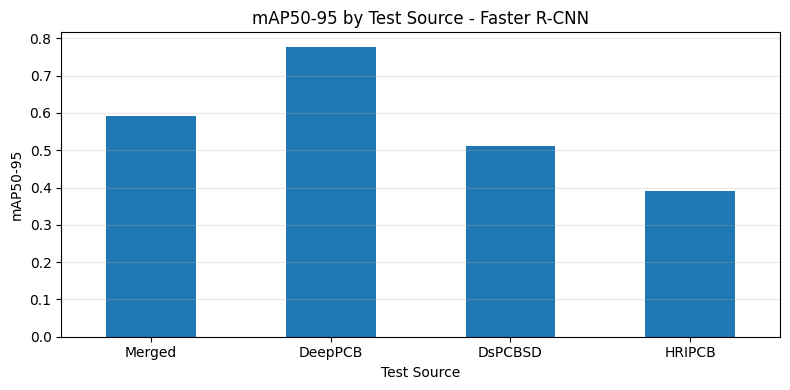

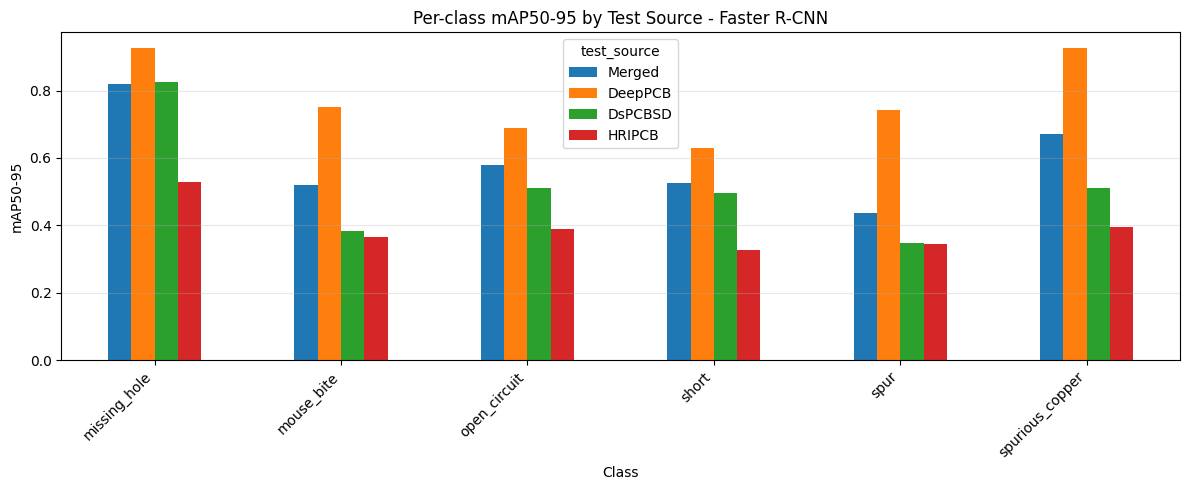

test_source,Merged,DeepPCB,DsPCBSD,HRIPCB
class_name,,,,
missing_hole,0.819462,0.925268,0.824138,0.528466
mouse_bite,0.518796,0.751805,0.382877,0.365426
open_circuit,0.579531,0.688168,0.512195,0.388868
short,0.525932,0.629863,0.494881,0.327460
spur,0.437508,0.742303,0.346766,0.345523
spurious_copper,0.669693,0.926300,0.511558,0.395651


In [13]:
def plot_sourcewise_metrics(summary_df, out_path):
    pivot = summary_df.pivot_table(
        index="test_source",
        values="mAP50_95",
        aggfunc="first",
    )

    desired_index = [x for x in ["Merged", "DeepPCB", "DsPCBSD", "HRIPCB", "UNKNOWN"] if x in pivot.index]
    pivot = pivot.reindex(desired_index)

    ax = pivot["mAP50_95"].plot(kind="bar", figsize=(8, 4))
    ax.set_title("mAP50-95 by Test Source - Faster R-CNN")
    ax.set_xlabel("Test Source")
    ax.set_ylabel("mAP50-95")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.show()

def plot_per_class_sourcewise(per_class_df, out_path):
    pivot = per_class_df.pivot_table(
        index="class_name",
        columns="test_source",
        values="mAP50_95",
        aggfunc="first",
    )

    desired_cols = [c for c in ["Merged", "DeepPCB", "DsPCBSD", "HRIPCB", "UNKNOWN"] if c in pivot.columns]
    pivot = pivot[desired_cols]

    ax = pivot.plot(kind="bar", figsize=(12, 5))
    ax.set_title("Per-class mAP50-95 by Test Source - Faster R-CNN")
    ax.set_xlabel("Class")
    ax.set_ylabel("mAP50-95")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.show()

    return pivot

plot_sourcewise_metrics(
    sourcewise_summary_df,
    REPORT_DIR / f"{TRAIN_NAME}_sourcewise_map50_95.png",
)

per_class_source_pivot = plot_per_class_sourcewise(
    sourcewise_per_class_df,
    REPORT_DIR / f"{TRAIN_NAME}_sourcewise_per_class_map50_95.png",
)

display(per_class_source_pivot)
per_class_source_pivot.to_csv(REPORT_DIR / f"{TRAIN_NAME}_sourcewise_per_class_pivot.csv")

## 13. Plot training curves

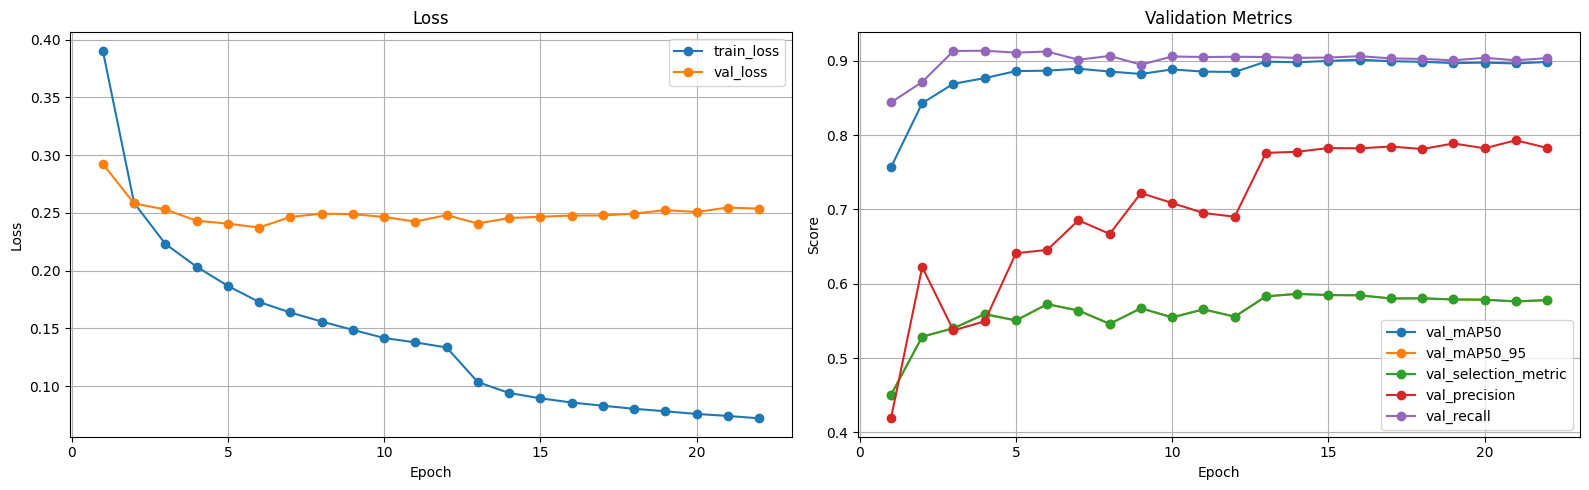

In [14]:
history_df = pd.read_csv(RESULTS_CSV)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for col in ["train_loss", "val_loss"]:
    if col in history_df.columns:
        ax.plot(history_df["epoch"], history_df[col], marker="o", label=col)

ax.set_title("Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True)
ax.legend()

ax = axes[1]
for col in ["val_mAP50", "val_mAP50_95", "val_selection_metric", "val_precision", "val_recall"]:
    if col in history_df.columns:
        ax.plot(history_df["epoch"], history_df[col], marker="o", label=col)

ax.set_title("Validation Metrics")
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig(REPORT_DIR / f"{TRAIN_NAME}_training_curves.png", dpi=160)
plt.show()

## 14. Prediction visualization

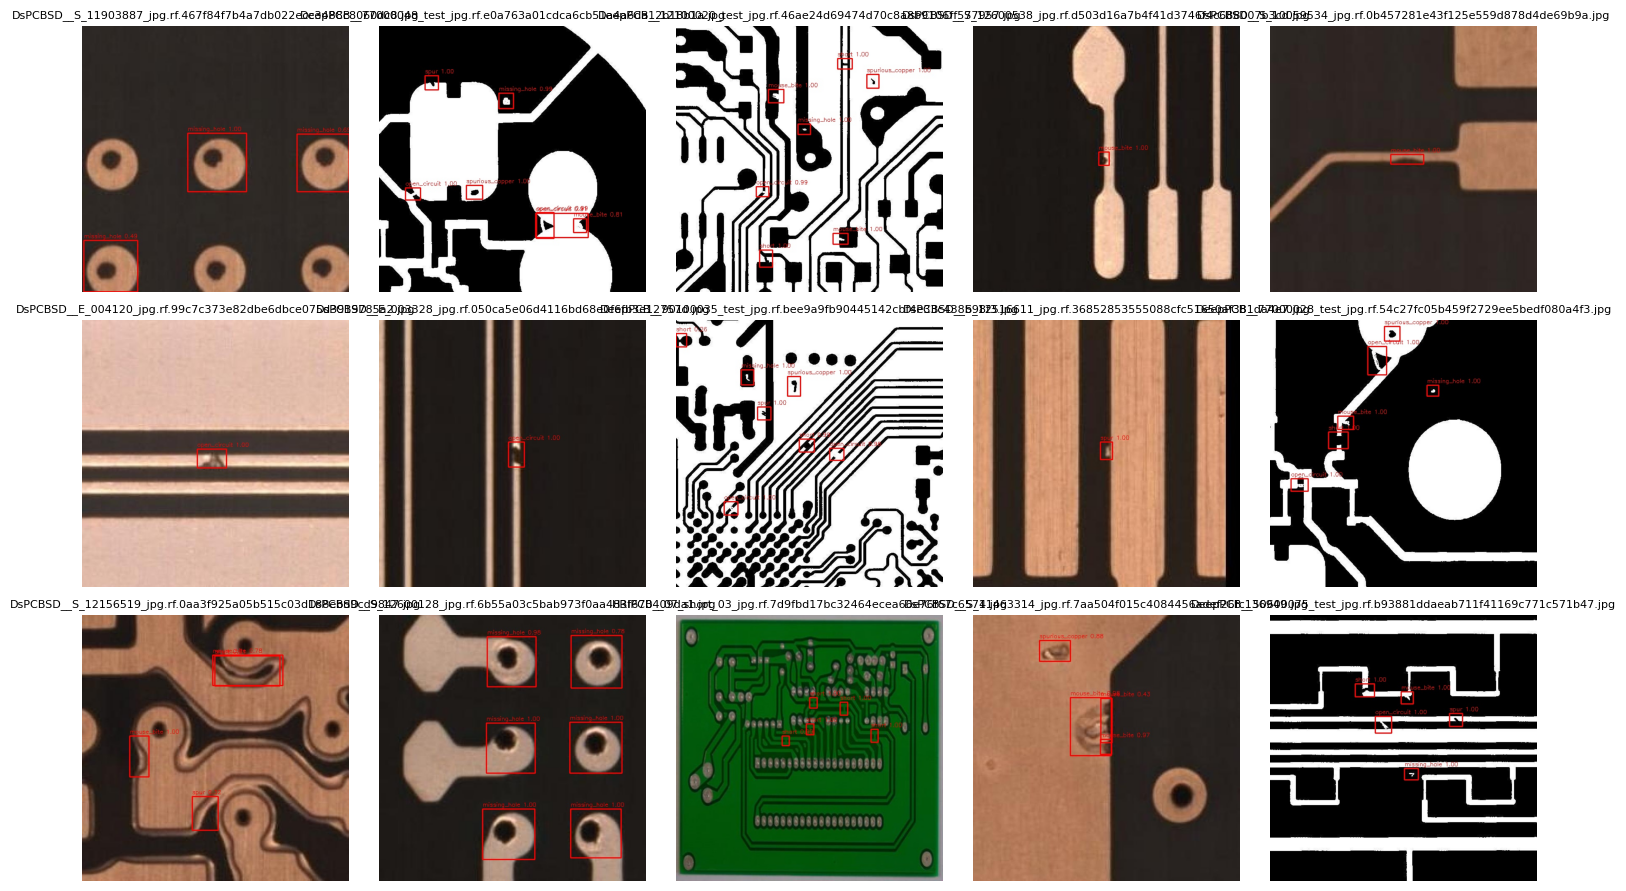

In [15]:
@torch.no_grad()
def draw_prediction_image(model, img_path: Path, out_path: Path, conf_thr=0.25):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)

    tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float() / 255.0
    tensor = tensor.to(DEVICE)

    output = model([tensor])[0]

    boxes = output["boxes"].detach().cpu().numpy()
    labels = output["labels"].detach().cpu().numpy()
    scores = output["scores"].detach().cpu().numpy()

    canvas = img_resized.copy()

    for box, label, score in zip(boxes, labels, scores):
        if score < conf_thr:
            continue

        cls_id = int(label) - 1
        if not (0 <= cls_id < len(CLASS_NAMES)):
            continue

        x1, y1, x2, y2 = box.astype(int)

        cv2.rectangle(canvas, (x1, y1), (x2, y2), (255, 0, 0), 2)
        text = f"{CLASS_NAMES[cls_id]} {score:.2f}"
        cv2.putText(canvas, text, (x1, max(0, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 0), 1)

    out_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(out_path), cv2.cvtColor(canvas, cv2.COLOR_RGB2BGR))

test_images = list_images(DATA_DIR / "test" / "images")
sample_images = random.sample(test_images, k=min(15, len(test_images)))

saved_paths = []
for img_path in sample_images:
    out_path = PRED_DIR / img_path.name
    draw_prediction_image(best_model, img_path, out_path, conf_thr=CONF_THR)
    saved_paths.append(out_path)

rows, cols = 3, 5
plt.figure(figsize=(15, 9))

for i, img_path in enumerate(saved_paths[:15]):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(img_path.name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.savefig(REPORT_DIR / f"{TRAIN_NAME}_sample_predictions.png", dpi=160)
plt.show()

## 15. Export artifacts

In [16]:
EXPORT_DIR = ARTIFACT_DIR / TRAIN_NAME
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

for p in [
    RESULTS_CSV,
    BEST_PT,
    LAST_PT,
]:
    if Path(p).exists():
        shutil.copy2(p, EXPORT_DIR / Path(p).name)

# Copy report CSV/PNG/JSON.
for p in REPORT_DIR.glob("*"):
    if p.is_file():
        shutil.copy2(p, EXPORT_DIR / p.name)

# Copy up to 15 prediction images.
pred_out = EXPORT_DIR / "sample_predictions"
pred_out.mkdir(parents=True, exist_ok=True)

copied = 0
for p in sorted(PRED_DIR.glob("*")):
    if p.is_file() and p.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        shutil.copy2(p, pred_out / p.name)
        copied += 1
        if copied >= 15:
            break

ZIP_OUTPUT = ROOT / f"{TRAIN_NAME}_artifacts.zip"
if ZIP_OUTPUT.exists():
    ZIP_OUTPUT.unlink()

shutil.make_archive(
    base_name=str(ZIP_OUTPUT.with_suffix("")),
    format="zip",
    root_dir=str(ARTIFACT_DIR),
    base_dir=TRAIN_NAME,
)

print("Exported:", EXPORT_DIR)
print("Created zip:", ZIP_OUTPUT)
print("Size MB:", ZIP_OUTPUT.stat().st_size / (1024 * 1024))

print("\nImportant files:")
for p in sorted(EXPORT_DIR.glob("*")):
    print("-", p.name)

Exported: /kaggle/working/faster_rcnn_artifacts/faster_rcnn_resnet50_fpn_final_clean_6cls_e42
Created zip: /kaggle/working/faster_rcnn_resnet50_fpn_final_clean_6cls_e42_artifacts.zip
Size MB: 588.67689037323

Important files:
- class_distribution.csv
- dataset_summary.csv
- faster_rcnn_resnet50_fpn_final_clean_6cls_e42_best.pth
- faster_rcnn_resnet50_fpn_final_clean_6cls_e42_last.pth
- faster_rcnn_resnet50_fpn_final_clean_6cls_e42_results.csv
- faster_rcnn_resnet50_fpn_final_clean_6cls_e42_sample_predictions.png
- faster_rcnn_resnet50_fpn_final_clean_6cls_e42_sourcewise_map50_95.png
- faster_rcnn_resnet50_fpn_final_clean_6cls_e42_sourcewise_metrics.json
- faster_rcnn_resnet50_fpn_final_clean_6cls_e42_sourcewise_per_class_map.csv
- faster_rcnn_resnet50_fpn_final_clean_6cls_e42_sourcewise_per_class_map50_95.png
- faster_rcnn_resnet50_fpn_final_clean_6cls_e42_sourcewise_per_class_pivot.csv
- faster_rcnn_resnet50_fpn_final_clean_6cls_e42_sourcewise_summary_metrics.csv
- faster_rcnn_resnet5

## Files to download

Download the artifact zip:

```text
/kaggle/working/faster_rcnn_resnet50_fpn_final_clean_6cls_e42_artifacts.zip
```

Important exported files:

- `faster_rcnn_resnet50_fpn_final_clean_6cls_e42_sourcewise_summary_metrics.csv`
- `faster_rcnn_resnet50_fpn_final_clean_6cls_e42_sourcewise_per_class_map.csv`
- `faster_rcnn_resnet50_fpn_final_clean_6cls_e42_sourcewise_per_class_pivot.csv`
- `faster_rcnn_resnet50_fpn_final_clean_6cls_e42_sourcewise_map50_95.png`
- `faster_rcnn_resnet50_fpn_final_clean_6cls_e42_sourcewise_per_class_map50_95.png`
- `faster_rcnn_resnet50_fpn_final_clean_6cls_e42_training_curves.png`